In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
client_data = "https://cdn.theforage.com/vinternships/companyassets/SKZxezskWgmFjRvj9/BqF6gmrmLunCkdqKM/1639044685365/client_data.csv"
price_data = "https://cdn.theforage.com/vinternships/companyassets/SKZxezskWgmFjRvj9/BqF6gmrmLunCkdqKM/1639044717433/price_data.csv"


In [3]:
client_data = pd.read_csv(client_data)
price_data = pd.read_csv(price_data)

In [4]:
# Select relevant features for market segmentation
selected_features = ['cons_12m', 'cons_gas_12m', 'forecast_cons_12m', 'forecast_cons_year',
                     'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
                     'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons',
                     'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig',
                     'pow_max']


In [5]:
# Subset the data with selected features
segmentation_data = client_data[selected_features].copy()
segmentation_data

# Data preprocessing: Standardize the data
scaler = StandardScaler()
segmentation_data_scaled  = scaler.fit_transform(segmentation_data)

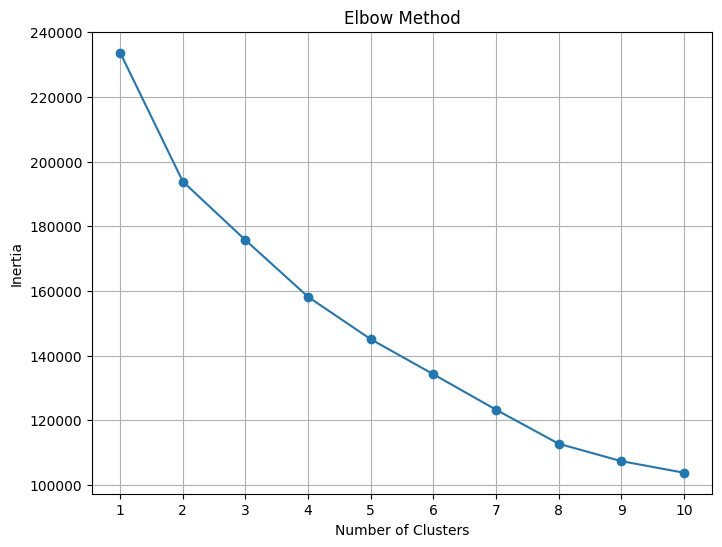

In [11]:
# Determine the optimal number of clusters using the elbow method
inertia = []
for n_clusters in range(1, 11):  # Test 1 to 10 clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(segmentation_data_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [12]:

# Based on the elbow curve, select the optimal number of clusters
optimal_clusters = 2


# Perform K-means clustering
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(segmentation_data_scaled)

# Assign cluster labels to the original data
segmentation_data['cluster_label'] = kmeans.labels_



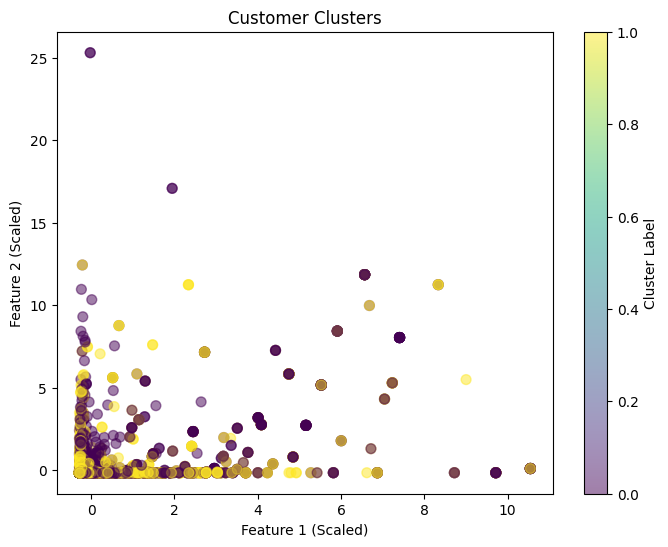

,cons_12m,cons_gas_12m,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,cluster_label
0,0,54946,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,0.00,25.44,25.44,2,678.99,3,43.648,0
1,4660,0,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,0.00,16.38,16.38,1,18.89,6,13.800,1
2,544,0,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,0.00,28.60,28.60,1,6.60,6,13.856,1
3,1584,0,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,0.00,30.22,30.22,1,25.46,6,13.200,1
4,4425,0,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,52.32,44.91,44.91,1,47.98,6,19.800,0


In [13]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(segmentation_data_scaled[:, 0], segmentation_data_scaled[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.5)
plt.title('Customer Clusters')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.colorbar(label='Cluster Label')
plt.show()

# Display the first few rows with cluster labels
display(segmentation_data.head())